In [1]:
# import classy module
from classy import Class
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib.pyplot as plt
from math import pi
import numpy as np

In [2]:
# create instance of the class "Class"
LambdaCDM = Class()
# pass input parameters
LambdaCDM.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
LambdaCDM.set({'output':'tCl,pCl,lCl,mPk','analytic_nowiggle':'yes','numerical_nowiggle':'yes','lensing':'yes'})
LambdaCDM.set({'P_k_max_1/Mpc':3.0,'z_max_pk':1.1})
LambdaCDM.set({'non_linear':'HMcode','hmcode_version':'2020'})
# run class
LambdaCDM.compute()

In [3]:
kk = np.logspace(-4,np.log10(3),1000) # k in h/Mpc
h = LambdaCDM.h() # get reduced Hubble for conversions to 1/Mpc
Pk = [] # P(k) in (Mpc/h)**3
Pk_lin = [] # P(k) in (Mpc/h)**3
Pk_nw = []
Pk_an_nw = []

In [4]:
# get P(k) at redhsift z
z=0
for k in kk:
    Pk_lin.append(LambdaCDM.pk_lin(k*h,z)*h**3) # function .pk(k,z)
    Pk_nw.append(LambdaCDM.pk_numerical_nw(k*h,z)*h**3) # function .pk(k,z)
    Pk_an_nw.append(LambdaCDM.pk_analytic_nw(k*h)*h**3) # function .pk(k,z)
    Pk.append(LambdaCDM.pk(k*h,z)*h**3) # function .pk(k,z)

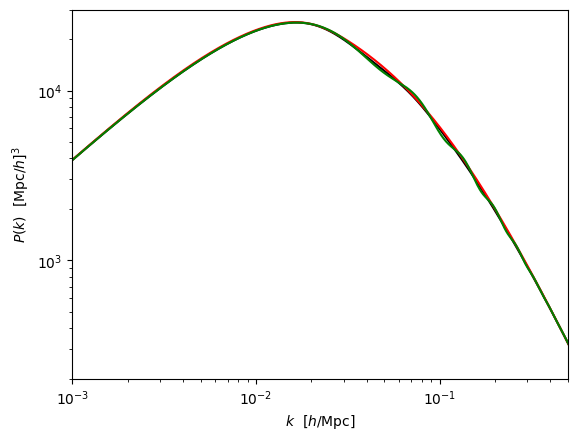

In [5]:
# plot P(k)
#plt.figure(1)
plt.xscale('log');plt.yscale('log')
#plt.xlim(kk[0],kk[-1])
plt.xlim(1.e-3,0.5)
plt.ylim(200,3e4)
plt.xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$')
plt.plot(kk,Pk_nw,'k-')
plt.plot(kk,Pk_an_nw,'r-')
plt.plot(kk,Pk_lin,'g-')
plt.savefig('test_hmcode.pdf',bbox_inches='tight')